In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# Random seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# Load data
# ============================================================

data = pd.read_csv(
    "../../data/processed/model_df_next_mmse.csv"
)

print(data.shape)

Device: cuda


FileNotFoundError: [Errno 2] No such file or directory: '../../data/processed/model_df_next_mmse.csv'

In [45]:
date_cols = [
    "visit_date",
    "target_date",
    "previous_visit_date",
    "casi_date",
    "blood_date"
]

for col in date_cols:

    if col in data.columns:

        data[col] = pd.to_datetime(
            data[col],
            errors="coerce"
        )


data = (
    data
    .dropna(
        subset=[
            "patient_id",
            "visit_date",
            "target_date",
            "target_mmse"
        ]
    )
    .sort_values(
        ["patient_id", "visit_date"]
    )
    .reset_index(drop=True)
)

In [46]:
# ============================================================
# 每位病人的 baseline MMSE date
# ============================================================

data["baseline_date"] = (
    data
    .groupby("patient_id")["visit_date"]
    .transform("min")
)


# ============================================================
# 目前 index visit 的累積 follow-up time
# ============================================================

data["visit_followup_time"] = (
    data["visit_date"]
    - data["baseline_date"]
).dt.days


# ============================================================
# target observation 的累積 follow-up time
# ============================================================

data["target_followup_time"] = (
    data["target_date"]
    - data["baseline_date"]
).dt.days

In [47]:
GROUP_COL = "bio_category"

GROUPS = [
    "AD",
    "non-AD",
    "CU"
]

for group in GROUPS:

    tmp = data[
        data[GROUP_COL] == group
    ]

    print(
        group,
        "| patients:",
        tmp["patient_id"].nunique(),
        "| rows:",
        len(tmp)
    )

AD | patients: 414 | rows: 2068
non-AD | patients: 439 | rows: 2028
CU | patients: 62 | rows: 145


In [48]:
casi_features = [
    "casi_mental_manipulation",
    "casi_attention",
    "casi_orientation",
    "casi_long_term_memory",
    "casi_short_term_memory",
    "casi_abstraction",
    "casi_drawing",
    "casi_verbal_fluency",
    "casi_language",
    "casi_total"
]


cdr_features = [
    "cdr_global",
    "cdr_memory",
    "cdr_orientation",
    "cdr_judgment",
    "cdr_community",
    "cdr_home_hobbies",
    "cdr_personal_care",
    "cdr_sob"
]


dynamic_features = [

    # Autoregressive outcome
    "mmse",

    # CDR
    *cdr_features,

    # CASI
    *casi_features,

    # CASI temporal information
    "days_since_casi",
    "has_recent_casi"
]

# 註解掉因為cu組缺失了整欄的onset，後續建模會出問題
# target_numeric_features = [

#     # 最重要：
#     # 目標觀測點累積追蹤時間
#     "target_followup_time",

#     # baseline / patient covariates
#     "age_first_mmse",
#     "education",
#     "apoe4_count",
#     "apoe4_carrier",
#     "age_onset",
#     "disease_duration_at_baseline"
# ]

target_numeric_features = [
    "target_followup_time",
    "age_first_mmse",
    "education",
    "apoe4_count",
    "apoe4_carrier"
]

data["gender_encoded"] = pd.to_numeric(
    data["gender"],
    errors="coerce"
)

target_features = (
    target_numeric_features
    + ["gender_encoded"]
)

In [49]:
def patient_split(
    df,
    random_state=42
):

    # ================================================
    # 70% train / 30% temp
    # ================================================

    split1 = GroupShuffleSplit(
        n_splits=1,
        test_size=0.30,
        random_state=random_state
    )

    train_idx, temp_idx = next(
        split1.split(
            df,
            groups=df["patient_id"]
        )
    )

    train_df = (
        df.iloc[train_idx]
        .copy()
    )

    temp_df = (
        df.iloc[temp_idx]
        .copy()
    )


    # ================================================
    # temp → 15% validation / 15% test
    # ================================================

    split2 = GroupShuffleSplit(
        n_splits=1,
        test_size=0.50,
        random_state=random_state
    )

    val_idx, test_idx = next(
        split2.split(
            temp_df,
            groups=temp_df["patient_id"]
        )
    )


    val_df = (
        temp_df
        .iloc[val_idx]
        .copy()
    )

    test_df = (
        temp_df
        .iloc[test_idx]
        .copy()
    )


    # 排序
    train_df = (
        train_df
        .sort_values(
            ["patient_id", "visit_date"]
        )
        .reset_index(drop=True)
    )

    val_df = (
        val_df
        .sort_values(
            ["patient_id", "visit_date"]
        )
        .reset_index(drop=True)
    )

    test_df = (
        test_df
        .sort_values(
            ["patient_id", "visit_date"]
        )
        .reset_index(drop=True)
    )


    return (
        train_df,
        val_df,
        test_df
    )

In [50]:
def preprocess_group(
    train_df,
    val_df,
    test_df,
    dynamic_features,
    casi_features,
    cdr_features,
    target_features
):

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()


    # ========================================================
    # Numeric conversion
    # ========================================================

    numeric_cols = list(
        set(
            dynamic_features
            + target_features
            + ["target_mmse"]
        )
    )

    for df in [
        train_df,
        val_df,
        test_df
    ]:

        for col in numeric_cols:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )


    # ========================================================
    # CASI missing indicator
    # ========================================================

    for df in [
        train_df,
        val_df,
        test_df
    ]:

        df["has_recent_casi"] = (
            df["has_recent_casi"]
            .fillna(0)
            .astype(float)
        )

        # 180 天內沒有 CASI
        df["days_since_casi"] = (
            df["days_since_casi"]
            .fillna(181)
        )


    # ========================================================
    # CASI scores:
    # train median 只是 placeholder
    # has_recent_casi 保留 missingness information
    # ========================================================

    casi_imputer = SimpleImputer(
        strategy="median"
    )

    casi_imputer.fit(
        train_df[casi_features]
    )

    train_df[casi_features] = (
        casi_imputer.transform(
            train_df[casi_features]
        )
    )

    val_df[casi_features] = (
        casi_imputer.transform(
            val_df[casi_features]
        )
    )

    test_df[casi_features] = (
        casi_imputer.transform(
            test_df[casi_features]
        )
    )


    # ========================================================
    # CDR
    # ========================================================

    cdr_imputer = SimpleImputer(
        strategy="median"
    )

    cdr_imputer.fit(
        train_df[cdr_features]
    )

    train_df[cdr_features] = (
        cdr_imputer.transform(
            train_df[cdr_features]
        )
    )

    val_df[cdr_features] = (
        cdr_imputer.transform(
            val_df[cdr_features]
        )
    )

    test_df[cdr_features] = (
        cdr_imputer.transform(
            test_df[cdr_features]
        )
    )


    # ========================================================
    # Target covariates
    # ========================================================

    target_imputer = SimpleImputer(
        strategy="median"
    )

    target_imputer.fit(
        train_df[target_features]
    )

    train_df[target_features] = (
        target_imputer.transform(
            train_df[target_features]
        )
    )

    val_df[target_features] = (
        target_imputer.transform(
            val_df[target_features]
        )
    )

    test_df[target_features] = (
        target_imputer.transform(
            test_df[target_features]
        )
    )


    # ========================================================
    # Dynamic scaling
    # ========================================================

    dynamic_scaler = StandardScaler()

    dynamic_scaler.fit(
        train_df[dynamic_features]
    )

    train_df[dynamic_features] = (
        dynamic_scaler.transform(
            train_df[dynamic_features]
        )
    )

    val_df[dynamic_features] = (
        dynamic_scaler.transform(
            val_df[dynamic_features]
        )
    )

    test_df[dynamic_features] = (
        dynamic_scaler.transform(
            test_df[dynamic_features]
        )
    )


    # ========================================================
    # X* scaling
    # ========================================================

    target_scaler = StandardScaler()

    target_scaler.fit(
        train_df[target_features]
    )

    train_df[target_features] = (
        target_scaler.transform(
            train_df[target_features]
        )
    )

    val_df[target_features] = (
        target_scaler.transform(
            val_df[target_features]
        )
    )

    test_df[target_features] = (
        target_scaler.transform(
            test_df[target_features]
        )
    )


    return {
        "train": train_df,
        "val": val_df,
        "test": test_df,

        "dynamic_scaler":
            dynamic_scaler,

        "target_scaler":
            target_scaler,

        "casi_imputer":
            casi_imputer,

        "cdr_imputer":
            cdr_imputer,

        "target_imputer":
            target_imputer
    }

In [51]:
SEQ_LEN = 3

def fit_time_gap_scaler(
    train_df
):

    gaps = []

    for patient_id, g in train_df.groupby(
        "patient_id"
    ):

        g = g.sort_values(
            "visit_date"
        )

        patient_gaps = (
            g["visit_date"]
            .diff()
            .dt.days
            .dropna()
            .to_numpy(dtype=float)
        )

        gaps.extend(
            patient_gaps
        )


    gaps = np.array(
        gaps,
        dtype=float
    ).reshape(-1, 1)


    scaler = StandardScaler()

    scaler.fit(gaps)

    return scaler

In [52]:
def build_sequences(
    df,
    dynamic_features,
    target_features,
    time_gap_scaler,
    seq_len=3
):

    samples = []

    df = (
        df
        .sort_values(
            ["patient_id", "visit_date"]
        )
        .reset_index(drop=True)
    )


    for patient_id, g in df.groupby(
        "patient_id"
    ):

        g = (
            g
            .sort_values(
                "visit_date"
            )
            .reset_index(drop=True)
        )


        for i in range(len(g)):

            # =================================================
            # 最近 seq_len 個 historical visits
            # =================================================

            start_idx = max(
                0,
                i - seq_len + 1
            )

            history = (
                g.iloc[
                    start_idx:i + 1
                ]
                .copy()
            )


            # =================================================
            # MMSE measurement time gaps
            # =================================================

            raw_gaps = (
                history["visit_date"]
                .diff()
                .dt.days
                .fillna(0)
                .to_numpy(dtype=float)
            )


            gap_scaled = np.zeros(
                len(raw_gaps),
                dtype=np.float32
            )


            # 第一個 timestep 沒 previous observation
            # 固定設 0
            if len(raw_gaps) > 1:

                gap_scaled[1:] = (
                    time_gap_scaler
                    .transform(
                        raw_gaps[1:]
                        .reshape(-1, 1)
                    )
                    .ravel()
                )


            # =================================================
            # Dynamic longitudinal sequence
            # =================================================

            x_base = (
                history[
                    dynamic_features
                ]
                .to_numpy(
                    dtype=np.float32
                )
            )


            # 最後一個 feature = time gap
            x_sequence = (
                np.column_stack(
                    [
                        x_base,
                        gap_scaled
                    ]
                )
                .astype(np.float32)
            )


            # =================================================
            # X*：
            # target observation covariates
            # =================================================

            x_target = (
                g.loc[
                    i,
                    target_features
                ]
                .to_numpy(
                    dtype=np.float32
                )
            )


            # =================================================
            # Target MMSE
            # =================================================

            y = float(
                g.loc[
                    i,
                    "target_mmse"
                ]
            )


            if np.isnan(y):
                continue


            samples.append({

                "patient_id":
                    patient_id,

                "visit_date":
                    g.loc[
                        i,
                        "visit_date"
                    ],

                "target_date":
                    g.loc[
                        i,
                        "target_date"
                    ],

                "sequence":
                    x_sequence,

                "target_covariates":
                    x_target,

                "target":
                    y,

                "length":
                    len(history)

            })


    return samples

In [53]:
class MMSESequenceDataset(
    Dataset
):

    def __init__(
        self,
        samples
    ):

        self.samples = samples


    def __len__(self):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        idx
    ):

        sample = self.samples[idx]


        sequence = torch.tensor(
            sample["sequence"],
            dtype=torch.float32
        )


        target_covariates = torch.tensor(
            sample["target_covariates"],
            dtype=torch.float32
        )


        target = torch.tensor(
            sample["target"],
            dtype=torch.float32
        )


        length = sample["length"]


        return (
            sequence,
            target_covariates,
            target,
            length
        )

In [54]:
def collate_fn(
    batch
):

    (
        sequences,
        target_covariates,
        targets,
        lengths
    ) = zip(*batch)


    sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0
    )


    target_covariates = torch.stack(
        target_covariates
    )


    targets = torch.stack(
        targets
    )


    lengths = torch.tensor(
        lengths,
        dtype=torch.long
    )


    return (
        sequences,
        target_covariates,
        targets,
        lengths
    )

In [55]:
class LSTMNARX(
    nn.Module
):

    def __init__(
        self,
        dynamic_input_size,
        target_input_size,
        hidden_size=64,
        num_layers=1,
        dropout=0.2
    ):

        super().__init__()


        # ====================================================
        # Historical branch
        # ====================================================

        self.lstm = nn.LSTM(

            input_size=
                dynamic_input_size,

            hidden_size=
                hidden_size,

            num_layers=
                num_layers,

            batch_first=True,

            dropout=(
                dropout
                if num_layers > 1
                else 0
            )
        )


        # ====================================================
        # Target covariate branch X*
        # ====================================================

        self.target_net = nn.Sequential(

            nn.Linear(
                target_input_size,
                16
            ),

            nn.ReLU()
        )


        # ====================================================
        # Fusion
        # ====================================================

        self.fusion = nn.Sequential(

            nn.Linear(
                hidden_size + 16,
                32
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                32,
                1
            )
        )


    def forward(
        self,
        sequence,
        target_covariates,
        lengths
    ):


        # ====================================================
        # Variable sequence lengths
        # ====================================================

        packed = (
            pack_padded_sequence(

                sequence,

                lengths.cpu(),

                batch_first=True,

                enforce_sorted=False
            )
        )


        # ====================================================
        # LSTM
        # ====================================================

        _, (h_n, _) = self.lstm(
            packed
        )


        history_rep = h_n[-1]


        # ====================================================
        # X*
        # ====================================================

        target_rep = self.target_net(
            target_covariates
        )


        # ====================================================
        # Fusion
        # ====================================================

        combined = torch.cat(
            [
                history_rep,
                target_rep
            ],
            dim=1
        )


        prediction = self.fusion(
            combined
        )


        return prediction.squeeze(1)

In [56]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    total_loss = 0.0
    total_n = 0


    for (
        sequences,
        target_covariates,
        targets,
        lengths
    ) in loader:


        sequences = (
            sequences.to(device)
        )

        target_covariates = (
            target_covariates.to(device)
        )

        targets = (
            targets.to(device)
        )


        optimizer.zero_grad()


        predictions = model(
            sequences,
            target_covariates,
            lengths
        )


        loss = criterion(
            predictions,
            targets
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )


        optimizer.step()


        n = targets.size(0)

        total_loss += (
            loss.item() * n
        )

        total_n += n


    return (
        total_loss
        / total_n
    )

def evaluate_loss(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0.0
    total_n = 0


    with torch.no_grad():

        for (
            sequences,
            target_covariates,
            targets,
            lengths
        ) in loader:


            sequences = (
                sequences.to(device)
            )

            target_covariates = (
                target_covariates.to(device)
            )

            targets = (
                targets.to(device)
            )


            predictions = model(
                sequences,
                target_covariates,
                lengths
            )


            loss = criterion(
                predictions,
                targets
            )


            n = targets.size(0)

            total_loss += (
                loss.item() * n
            )

            total_n += n


    return (
        total_loss
        / total_n
    )

def predict_model(
    model,
    loader
):

    model.eval()

    y_true = []
    y_pred = []


    with torch.no_grad():

        for (
            sequences,
            target_covariates,
            targets,
            lengths
        ) in loader:


            sequences = (
                sequences.to(device)
            )

            target_covariates = (
                target_covariates.to(device)
            )


            predictions = model(
                sequences,
                target_covariates,
                lengths
            )


            y_true.extend(
                targets.numpy()
            )


            y_pred.extend(
                predictions
                .cpu()
                .numpy()
            )


    return (
        np.array(y_true),
        np.array(y_pred)
    )

In [57]:
def run_group_model(
    data,
    group_name,
    group_col,
    dynamic_features,
    target_features,
    casi_features,
    cdr_features,
    seq_len=3,
    batch_size=32,
    hidden_size=64,
    max_epochs=200,
    patience=20
):


    print(
        "\n"
        + "=" * 70
    )

    print(
        f"GROUP: {group_name}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 1. Select group
    # ========================================================

    group_df = (
        data[
            data[group_col]
            == group_name
        ]
        .copy()
    )


    print(
        "Patients:",
        group_df[
            "patient_id"
        ].nunique()
    )

    print(
        "Rows:",
        len(group_df)
    )


    # ========================================================
    # 2. Patient-level split
    # ========================================================

    (
        train_df,
        val_df,
        test_df
    ) = patient_split(
        group_df,
        random_state=SEED
    )


    print(
        "\nTrain:",
        train_df[
            "patient_id"
        ].nunique(),
        "patients"
    )

    print(
        "Validation:",
        val_df[
            "patient_id"
        ].nunique(),
        "patients"
    )

    print(
        "Test:",
        test_df[
            "patient_id"
        ].nunique(),
        "patients"
    )


    # ========================================================
    # 3. Preprocess
    # ========================================================

    prep = preprocess_group(

        train_df,
        val_df,
        test_df,

        dynamic_features,
        casi_features,
        cdr_features,
        target_features
    )


    train_p = prep["train"]
    val_p = prep["val"]
    test_p = prep["test"]


    # ========================================================
    # 4. Time-gap scaler
    # ========================================================

    time_gap_scaler = (
        fit_time_gap_scaler(
            train_p
        )
    )


    # ========================================================
    # 5. Sequence
    # ========================================================

    train_samples = build_sequences(
        train_p,
        dynamic_features,
        target_features,
        time_gap_scaler,
        seq_len
    )

    val_samples = build_sequences(
        val_p,
        dynamic_features,
        target_features,
        time_gap_scaler,
        seq_len
    )

    test_samples = build_sequences(
        test_p,
        dynamic_features,
        target_features,
        time_gap_scaler,
        seq_len
    )


    print(
        "\nSamples:"
    )

    print(
        "Train:",
        len(train_samples)
    )

    print(
        "Validation:",
        len(val_samples)
    )

    print(
        "Test:",
        len(test_samples)
    )


    # ========================================================
    # 6. Dataset
    # ========================================================

    train_dataset = (
        MMSESequenceDataset(
            train_samples
        )
    )

    val_dataset = (
        MMSESequenceDataset(
            val_samples
        )
    )

    test_dataset = (
        MMSESequenceDataset(
            test_samples
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )


    # ========================================================
    # 7. Model
    # ========================================================

    model = LSTMNARX(

        # +1 = historical time gap
        dynamic_input_size=
            len(dynamic_features) + 1,

        target_input_size=
            len(target_features),

        hidden_size=
            hidden_size,

        num_layers=1,

        dropout=0.2

    ).to(device)


    criterion = nn.MSELoss()


    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=1e-3,

        weight_decay=1e-4
    )


    # ========================================================
    # 8. Early stopping
    # ========================================================

    best_val_loss = np.inf

    best_state = None

    patience_counter = 0

    train_losses = []
    val_losses = []


    for epoch in range(
        max_epochs
    ):


        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )


        val_loss = evaluate_loss(
            model,
            val_loader,
            criterion
        )


        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )


        if (
            val_loss
            < best_val_loss
        ):

            best_val_loss = val_loss

            best_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

            patience_counter = 0

        else:

            patience_counter += 1


        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
        ):

            print(
                f"Epoch {epoch+1:3d} | "
                f"Train MSE: {train_loss:.4f} | "
                f"Val MSE: {val_loss:.4f}"
            )


        if (
            patience_counter
            >= patience
        ):

            print(
                "Early stopping:",
                epoch + 1
            )

            break


    # ========================================================
    # Restore best
    # ========================================================

    model.load_state_dict(
        best_state
    )


    # ========================================================
    # 9. Test prediction
    # ========================================================

    y_true, y_pred = predict_model(
        model,
        test_loader
    )


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    r2 = r2_score(
        y_true,
        y_pred
    )


    print(
        "\nTest results"
    )

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )


    # ========================================================
    # 10. Last-MMSE baseline
    # ========================================================

    mmse_idx = (
        dynamic_features.index(
            "mmse"
        )
    )


    mmse_mean = (
        prep[
            "dynamic_scaler"
        ].mean_[mmse_idx]
    )

    mmse_scale = (
        prep[
            "dynamic_scaler"
        ].scale_[mmse_idx]
    )


    baseline_pred_std = np.array([

        sample[
            "sequence"
        ][-1, mmse_idx]

        for sample
        in test_samples

    ])


    baseline_pred = (
        baseline_pred_std
        * mmse_scale
        + mmse_mean
    )


    baseline_mae = (
        mean_absolute_error(
            y_true,
            baseline_pred
        )
    )


    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_pred
        )
    )


    baseline_r2 = r2_score(
        y_true,
        baseline_pred
    )


    print(
        "\nLast-MMSE baseline"
    )

    print(
        f"MAE  : {baseline_mae:.4f}"
    )

    print(
        f"RMSE : {baseline_rmse:.4f}"
    )

    print(
        f"R²   : {baseline_r2:.4f}"
    )


    # ========================================================
    # Results
    # ========================================================

    result_df = pd.DataFrame({

        "patient_id": [
            x["patient_id"]
            for x in test_samples
        ],

        "visit_date": [
            x["visit_date"]
            for x in test_samples
        ],

        "target_date": [
            x["target_date"]
            for x in test_samples
        ],

        "true_mmse":
            y_true,

        "pred_mmse":
            y_pred,

        "baseline_pred":
            baseline_pred
    })


    return {

        "group":
            group_name,

        "model":
            model,

        "preprocessing":
            prep,

        "time_gap_scaler":
            time_gap_scaler,

        "train_losses":
            train_losses,

        "val_losses":
            val_losses,

        "result_df":
            result_df,

        "metrics": {

            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,

            "Baseline_MAE":
                baseline_mae,

            "Baseline_RMSE":
                baseline_rmse,

            "Baseline_R2":
                baseline_r2
        },

        "n_train_patients":
            train_p[
                "patient_id"
            ].nunique(),

        "n_val_patients":
            val_p[
                "patient_id"
            ].nunique(),

        "n_test_patients":
            test_p[
                "patient_id"
            ].nunique()
    }

In [58]:
results = {}


for group_name in GROUPS:

    results[group_name] = (
        run_group_model(

            data=data,

            group_name=
                group_name,

            group_col=
                GROUP_COL,

            dynamic_features=
                dynamic_features,

            target_features=
                target_features,

            casi_features=
                casi_features,

            cdr_features=
                cdr_features,

            seq_len=3,

            batch_size=32,

            hidden_size=64,

            max_epochs=200,

            patience=20
        )
    )


GROUP: AD
Patients: 414
Rows: 2068

Train: 289 patients
Validation: 62 patients
Test: 63 patients

Samples:
Train: 1427
Validation: 291
Test: 350
Epoch   1 | Train MSE: 285.8070 | Val MSE: 235.9553
Epoch  10 | Train MSE: 13.4093 | Val MSE: 10.0441
Epoch  20 | Train MSE: 12.1125 | Val MSE: 7.8790
Epoch  30 | Train MSE: 10.8314 | Val MSE: 7.6398
Epoch  40 | Train MSE: 9.9829 | Val MSE: 7.7605
Epoch  50 | Train MSE: 9.3875 | Val MSE: 7.7043
Early stopping: 59

Test results
MAE  : 2.2566
RMSE : 3.1288
R²   : 0.8482

Last-MMSE baseline
MAE  : 2.3286
RMSE : 3.3836
R²   : 0.8225

GROUP: non-AD
Patients: 439
Rows: 2028

Train: 307 patients
Validation: 66 patients
Test: 66 patients

Samples:
Train: 1343
Validation: 289
Test: 396
Epoch   1 | Train MSE: 474.0583 | Val MSE: 382.4007
Epoch  10 | Train MSE: 16.4406 | Val MSE: 13.1226
Epoch  20 | Train MSE: 13.5148 | Val MSE: 11.5744
Epoch  30 | Train MSE: 13.1434 | Val MSE: 10.6051
Epoch  40 | Train MSE: 11.8806 | Val MSE: 11.2530
Early stopping: 4

In [60]:
summary = []


for group_name in GROUPS:

    r = results[
        group_name
    ]

    m = r[
        "metrics"
    ]


    summary.append({

        "Group":
            group_name,

        "Train patients":
            r["n_train_patients"],

        "Validation patients":
            r["n_val_patients"],

        "Test patients":
            r["n_test_patients"],

        "LSTM MAE":
            m["MAE"],

        "LSTM RMSE":
            m["RMSE"],

        "LSTM R2":
            m["R2"],

        "Baseline MAE":
            m["Baseline_MAE"],

        "Baseline RMSE":
            m["Baseline_RMSE"],

        "Baseline R2":
            m["Baseline_R2"]
    })


summary_df = pd.DataFrame(
    summary
)

summary_df

,Group,Train patients,Validation patients,Test patients,LSTM MAE,LSTM RMSE,LSTM R2,Baseline MAE,Baseline RMSE,Baseline R2
0,AD,289,62,63,2.256633,3.128776,0.848240,2.328572,3.383574,0.822515
1,non-AD,307,66,66,2.225976,2.981200,0.828742,2.047980,2.976762,0.829251
2,CU,43,9,10,3.508598,6.607790,-7.140538,1.454545,2.215647,0.084746


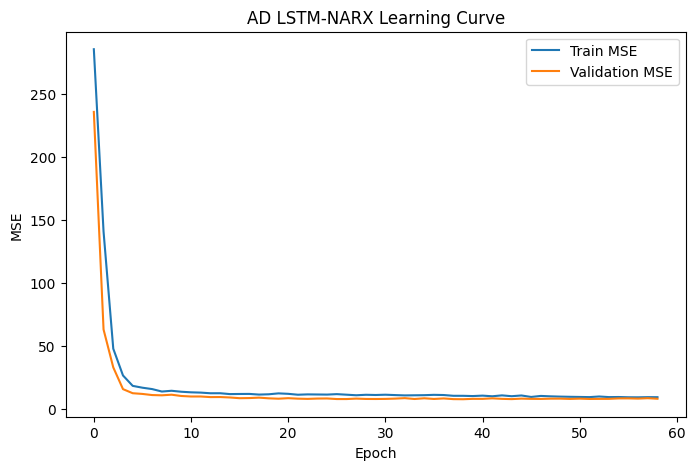

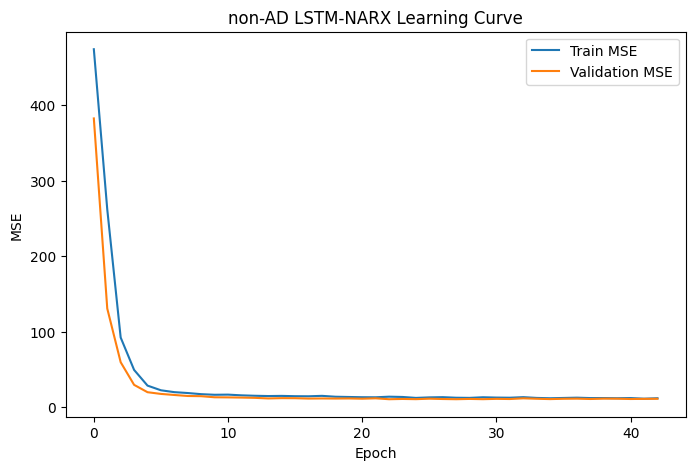

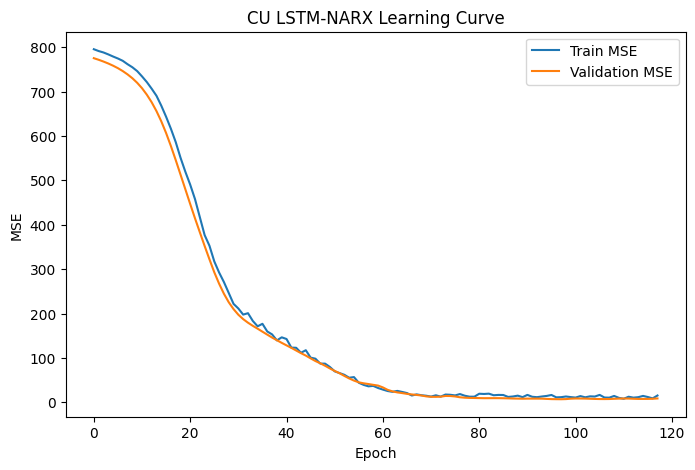

In [61]:
for group_name in GROUPS:

    r = results[
        group_name
    ]

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        r["train_losses"],
        label="Train MSE"
    )

    plt.plot(
        r["val_losses"],
        label="Validation MSE"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "MSE"
    )

    plt.title(
        f"{group_name} LSTM-NARX Learning Curve"
    )

    plt.legend()

    plt.show()